In [1]:
import numpy as np
import os, glob
import pandas as pd
from pathlib import Path
from collections import namedtuple
import matplotlib.cm as cm
import matplotlib.patches as patches
import matplotlib.pyplot as plt
from matplotlib import rcParams

plt.rcParams['text.usetex'] = False

# Add common Unicode fonts to the sans-serif priority list
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Noto Sans', 'DejaVu Sans', 'Arial Unicode MS', 'FreeSans']

In [2]:
def get_col(file, col_name, idx):
    # Reads only the necessary column to save memory
    try:
        df = pd.read_csv(file, usecols=[col_name], header=0, engine="python") # 'python' engine is safer if pyarrow isn't installed
        #return df[col_name].tolist()[idx] # Convert to list for easier handling later
        return df.at[idx, col_name]
    
    except ValueError:
        print(f"Warning: Column '{col_name}' not found in {file}")
        return []

class Stats:
    def __init__(self):
        self.x = []
        self.original = []
        self.perturbed = []
        self.restored = []

def get_stats(files, sample_type, idx, t=0.05):
    # Sort files by the numeric value in their name
    files.sort(key=lambda f: float(Path(f).name))
    
    file_stats = Stats()
    
    for f in files:    
        try:
            # Find the specific CSV for this checkpoint and sample type
            csv_path = glob.glob(os.path.join(f, f'stability_t={t}_*_{sample_type}.csv'))
            
            if not csv_path:
                print(f"No CSV found in {f} for t={t}")
                continue
                
            csv_file = csv_path[0] 
            print(f"Processing: {csv_file}")

            # --- CORRECTION HERE ---
            # You were fetching 'original' for both original and perturbed.
            # I assume your CSV has columns: 'original', 'perturbed', 'restored'
            original_txt = get_col(csv_file, 'original', idx)
            perturbed_txt = get_col(csv_file, 'perturbed', idx) # Fixed column name
            restored_txt = get_col(csv_file, 'restored', idx)
            
            if not original_txt or not perturbed_txt:
                continue

            x = float(Path(f).name)
            
            file_stats.x.append(x)
            file_stats.original.append(original_txt)
            file_stats.perturbed.append(perturbed_txt)
            file_stats.restored.append(restored_txt)
            
        except Exception as e:
            print(f"Error reading {f}: {e}")
            continue 

    return file_stats

In [3]:
def visualize_recovery(original_str, perturbed_str, restored_str, max_len=20, fontsize=18):
    """
    Visualizes text recovery. Inputs are strings (sentences), 
    so we split them into tokens first.
    """
    # Simple whitespace tokenization (adjust if you need specific subword tokenization)
    orig = original_str.split()[:max_len]
    pert = perturbed_str.split()[:max_len]
    rest = restored_str.split()[:max_len]
    
    # Pad lists if they are shorter than max_len (to avoid index errors)
    max_actual = max(len(orig), len(pert), len(rest))
    orig += [''] * (max_actual - len(orig))
    pert += [''] * (max_actual - len(pert))
    rest += [''] * (max_actual - len(rest))

    fig, ax = plt.subplots(figsize=(50, 6), dpi=150)
    ax.set_xlim(0, max_actual)
    ax.set_ylim(0, 3)
    ax.axis('off')
    
    # Row Labels
    ax.text(-0.5, 2.5, "Original", va='center', ha='right', fontweight='bold', fontsize=fontsize)
    ax.text(-0.5, 1.5, "Perturbed", va='center', ha='right', fontweight='bold', fontsize=fontsize)
    ax.text(-0.5, 0.5, "Restored", va='center', ha='right', fontweight='bold', fontsize=fontsize)

    for i in range(max_actual):
        # 1. Original
        ax.text(i + 0.5, 2.5, orig[i], va='center', ha='center', 
                bbox=dict(facecolor='white', edgecolor='lightgray', boxstyle='round,pad=0.3'), fontsize=fontsize)

        # 2. Perturbed
        is_perturbed = pert[i] != orig[i]
        # Orange if different, White if same
        c_pert = '#ffe0b2' if is_perturbed else 'white'
        e_pert = 'orange' if is_perturbed else 'lightgray'
        
        ax.text(i + 0.5, 1.5, pert[i], va='center', ha='center',
                bbox=dict(facecolor=c_pert, edgecolor=e_pert, boxstyle='round,pad=0.3'), fontsize=fontsize)

        # 3. Restored
        if is_perturbed:
            if rest[i] == orig[i]:
                # Was perturbed, now matches original -> GREEN (Success)
                c_rest = '#ffcdd2' # Light Red
                e_rest = 'red'
            else:
                # Was perturbed, still doesn't match -> RED (Fail)
                c_rest = '#c8e6c9' # Light Green
                e_rest = 'green'
        else:
            # Wasn't perturbed. 
            # Check for hallucination (unprovoked change)
            if rest[i] != orig[i]:
                c_rest = '#e1bee7' # Purple for hallucination
                e_rest = 'purple'
            else:
                c_rest = 'white'
                e_rest = 'lightgray'

        ax.text(i + 0.5, 0.5, rest[i], va='center', ha='center',
                bbox=dict(facecolor=c_rest, edgecolor=e_rest, boxstyle='round,pad=0.3'), fontsize=fontsize)

    plt.tight_layout()
    plt.show()

In [4]:
# --- Example Usage ---
# 1. Run your stats gathering
# files_list = glob.glob("path/to/checkpoints/*")
# stats_data = get_stats(files_list, sample_type='test')

# 2. Visualize a specific sample
# We need to pick:
# - Which checkpoint (index of stats_data.x)
# - Which sentence index (row in the dataframe)

# Example: Visualize the 1st sentence of the last checkpoint
# checkpoint_idx = -1 
# sentence_idx = 0 

# if len(stats_data.original) > 0:
#     orig_sample = stats_data.original[checkpoint_idx][sentence_idx]
#     pert_sample = stats_data.perturbed[checkpoint_idx][sentence_idx]
#     rest_sample = stats_data.restored[checkpoint_idx][sentence_idx]
#
#     visualize_recovery(orig_sample, pert_sample, rest_sample)

In [16]:
size = 'small'

files = glob.glob(f"../experiments/stability/lm1b-wrap-{size}/*")
ts = [0.25]

idx = 12

train_stats = [get_stats(files, 'train', idx, t) for t in ts]
print()

Processing: ../experiments/stability/lm1b-wrap-small/0.0001/stability_t=0.25_subset=0.0001_train.csv
Processing: ../experiments/stability/lm1b-wrap-small/0.002575/stability_t=0.25_subset=0.002575_train.csv
Processing: ../experiments/stability/lm1b-wrap-small/0.00505/stability_t=0.25_subset=0.00505_train.csv
Processing: ../experiments/stability/lm1b-wrap-small/0.007525/stability_t=0.25_subset=0.007525_train.csv
Processing: ../experiments/stability/lm1b-wrap-small/0.01/stability_t=0.25_subset=0.01_train.csv
Processing: ../experiments/stability/lm1b-wrap-small/0.04/stability_t=0.25_subset=0.04_train.csv
Processing: ../experiments/stability/lm1b-wrap-small/0.07/stability_t=0.25_subset=0.07_train.csv
Processing: ../experiments/stability/lm1b-wrap-small/0.1/stability_t=0.25_subset=0.1_train.csv
Processing: ../experiments/stability/lm1b-wrap-small/0.13/stability_t=0.25_subset=0.13_train.csv
Processing: ../experiments/stability/lm1b-wrap-small/0.16/stability_t=0.25_subset=0.16_train.csv
Proces

1.0


/tmp/ipykernel_67635/135922908.py:64: UserWarning: Glyph 26234 (\N{CJK UNIFIED IDEOGRAPH-667A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


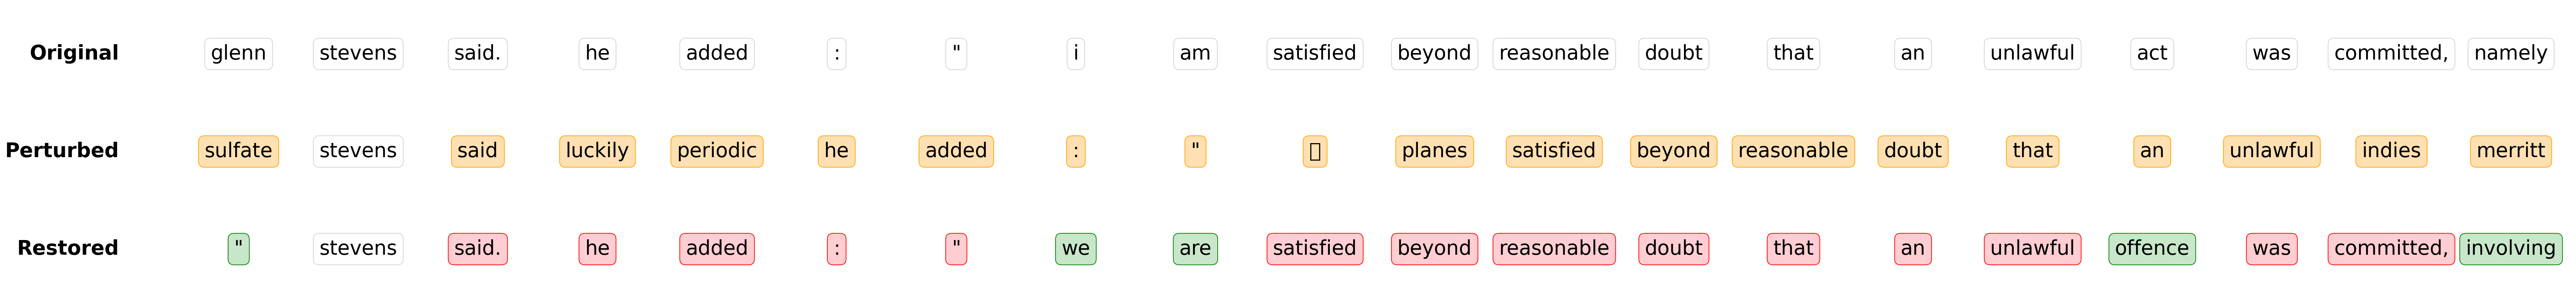

In [19]:
data_idx = -1
# 1, 21, -1
x_axis = [data.x for data in train_stats]

print(x_axis[0][data_idx])

train_original = train_stats[0].original[data_idx]
train_restored = train_stats[0].restored[data_idx]
train_perturbed = train_stats[0].perturbed[data_idx]

visualize_recovery(train_original, train_perturbed, train_restored, fontsize=28)

In [36]:
idx = 10
test_stats = [get_stats(files, 'test', idx, t) for t in ts]

Processing: ../experiments/stability/lm1b-wrap-small/0.0001/stability_t=0.25_subset=0.0001_test.csv
Processing: ../experiments/stability/lm1b-wrap-small/0.002575/stability_t=0.25_subset=0.002575_test.csv
Processing: ../experiments/stability/lm1b-wrap-small/0.00505/stability_t=0.25_subset=0.00505_test.csv
Processing: ../experiments/stability/lm1b-wrap-small/0.007525/stability_t=0.25_subset=0.007525_test.csv
Processing: ../experiments/stability/lm1b-wrap-small/0.01/stability_t=0.25_subset=0.01_test.csv
Processing: ../experiments/stability/lm1b-wrap-small/0.04/stability_t=0.25_subset=0.04_test.csv
Processing: ../experiments/stability/lm1b-wrap-small/0.07/stability_t=0.25_subset=0.07_test.csv
Processing: ../experiments/stability/lm1b-wrap-small/0.1/stability_t=0.25_subset=0.1_test.csv
Processing: ../experiments/stability/lm1b-wrap-small/0.13/stability_t=0.25_subset=0.13_test.csv
Processing: ../experiments/stability/lm1b-wrap-small/0.16/stability_t=0.25_subset=0.16_test.csv
Processing: ../e

0.52


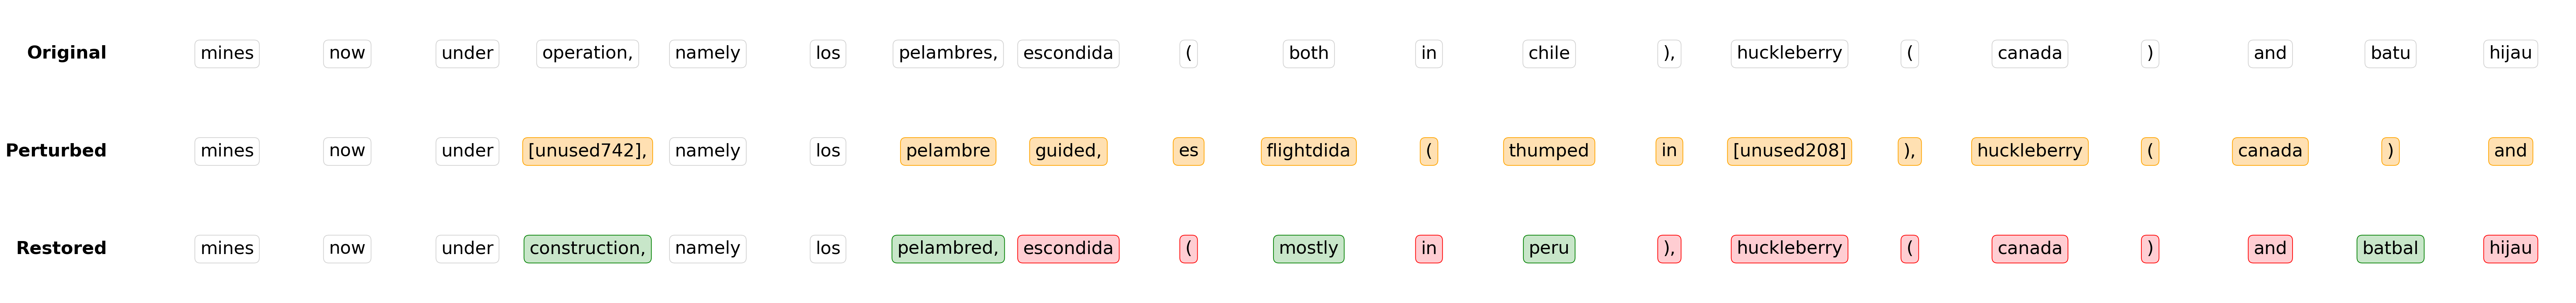

In [41]:
data_idx = 21
# idx = 1, 21, -1

x_axis = [data.x for data in train_stats]

print(x_axis[0][data_idx])
test_original = test_stats[0].original[data_idx]
test_restored = test_stats[0].restored[data_idx]
test_perturbed = test_stats[0].perturbed[data_idx]

visualize_recovery(test_original, test_perturbed, test_restored, fontsize=25)